In [ ]:
# немного расширяем рабочую область ноутбука
from IPython.display import HTML
display(HTML("<style>.container { width:92% !important; }</style>"))


<h2 style="text-align: center;"><b>Feature Selection и PCA. Практика</b></h2>


## <h1><u>План урока</u></h1>

1. Подготовка данных
2. Baseline-модель: точка отсчёта
3. SelectKBest: быстрый filter-отбор признаков
4. RFE: wrapper-отбор с учётом модели
5. PCA: понижение размерности через новые компоненты
6. Итоговая проверка


In [ ]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score


### <h3><b>1. Подготовка данных</b></h3>


Цель: получить стабильный baseline и корректно оценить, что реально дают SelectKBest, RFE и PCA.

Шаги:

1. Загрузим датасет. Используем встроенный учебный датасет Breast Cancer Wisconsin (Diagnostic) из sklearn.
В нём 569 наблюдений и 30 числовых признаков (характеристики клеточных ядер с изображений биопсии), а таргет — бинарный класс: 0 = malignant (злокачественная), 1 = benign (доброкачественная).

2. Добавим шумовые признаки  

3. Разделим на train/valid/test  
   `train_test_split(..., stratify=y)` сохраняет баланс классов на всех выборках.  
   `train` — обучение, `valid` — подбор параметров, `test` — финальная проверка.




In [ ]:
# Фиксируем рандом
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Загружаем датасет Breast Cancer в формате pandas DataFrame
data = load_breast_cancer(as_frame=True)
X_base = data.data.copy()     # исходные признаки
y = data.target.copy()        # целевая переменная (0/1)

print("Базовый размер X:", X_base.shape)

# Добавляем искусственные шумовые признаки, чтобы имитировать высокую размерность
n_noise = 70
rng = np.random.default_rng(RANDOM_STATE)

# Генерируем матрицу шума N(0,1) размером [число объектов x число шумовых признаков]
noise = pd.DataFrame(
    rng.normal(size=(len(X_base), n_noise)),
    columns=[f"noise_{i:02d}" for i in range(n_noise)],
    index=X_base.index
)

# Объединяем исходные и шумовые признаки по колонкам
X = pd.concat([X_base, noise], axis=1)

print("Размер X после добавления шума:", X.shape)



Базовый размер X: (569, 30)
Размер X после добавления шума: (569, 100)


In [ ]:
# Схема разбиения:
# 1) dev/test = 80/20
# 2) train/valid внутри dev = 75/25
# Итого: train=60%, valid=20%, test=20%

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% на финальный test
    stratify=y,            # сохраняем баланс классов
    random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev,
    test_size=0.25,        # 25% от dev => 20% от исходного датасета
    stratify=y_dev,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)


Train: (341, 100) Valid: (114, 100) Test: (114, 100)


### <h3><b>2. Baseline-модель: точка отсчёта</b></h3>

Здесь строится модель на всех признаках.  
Наша задача — получить метрики, с которыми дальше сравниваются все методы уменьшения размерности.

Шаги:

1. Обучаем модель, используя
   `Pipeline([StandardScaler(), LogisticRegression(...)])`  
   — сначала масштабирование, потом классификация.

2. Создаем функцию `fit_and_eval(...)`, которая считает:
   - `roc_auc` (качество ранжирования),
   - `f1` (баланс precision/recall при пороге),
   - `fit_sec` (время обучения).

3. Значения метрик этой модели, используются как эталон для будущих сравнений.

---

**Зачем нужен baseline** — без baseline нельзя понять, улучшает ли метод модель,  или просто уменьшает число признаков ценой качества.


In [ ]:
def fit_and_eval(pipe, X_fit, y_fit, X_eval, y_eval):
    """
    Обучает pipeline и возвращает словарь с метриками:
    - roc_auc: ROC-AUC на валидации/тесте
    - f1: F1-score на валидации/тесте
    - fit_sec: время обучения в секундах
    """
    # Засекаем время старта обучения
    t0 = perf_counter()

    # Обучаем pipeline
    pipe.fit(X_fit, y_fit)

    # Время обучения
    fit_sec = perf_counter() - t0

    # Классовые предсказания (для F1)
    y_pred = pipe.predict(X_eval)

    # Вероятности положительного класса (для ROC-AUC)
    y_prob = pipe.predict_proba(X_eval)[:, 1]

    return {
        "roc_auc": roc_auc_score(y_eval, y_prob),
        "f1": f1_score(y_eval, y_pred),
        "fit_sec": fit_sec
    }

def drop_pct(new_metric, base_metric):
    """
    Вычисляет процент падения метрики относительно baseline.
    Положительное значение = ухудшение.
    """
    return (base_metric - new_metric) / base_metric * 100


In [ ]:
# Baseline pipeline: стандартизация + логистическая регрессия на ВСЕХ признаках
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,      # увеличенный лимит итераций для надежной сходимости
        solver="liblinear", # алгоритма оптимизации, поддерживает L1 и L2 регуляризацию
        random_state=RANDOM_STATE
    ))
])

# Оцениваем baseline на validation-части
baseline_valid = fit_and_eval(baseline_pipe, X_train, y_train, X_valid, y_valid)

# Показываем базовые метрики
pd.DataFrame([baseline_valid]).round(4)


,roc_auc,f1,fit_sec
0,0.9859,0.979,0.0114


### <h3><b>3. SelectKBest: быстрый filter-отбор признаков</b></h3>

`SelectKBest` оставляет top-k признаков по статистическому критерию.  

- Перебираем несколько значений k и для каждого обучаем одну и ту же модель, чтобы сравнение было честным.
- Затем оцениваем метрики на валидации и выбираем самое компактное решение, которое укладывается в допустимую просадку качества, например не более 2%.
- Такой подход уменьшает шум, ускоряет обучение и делает модель проще для интерпретации.


**Шаги:**

1. Оценка информативности признаков - `SelectKBest(score_func=f_classif, k=k)` ранжирует признаки через ANOVA F-test.

2. Для каждого `k` обучается пайплайн и считаются метрики на `valid`.

3. Сравниваем относительно модели, обученной на всех прзнаках.

4. Берём минимальный `k`, где потеря ROC-AUC < 2%.

5. Используем `get_support()` для возвращения маски отобранных колонок.

---

Filter-подход очень быстрый и удобный для первичного сжатия признакового пространства.


In [ ]:
# Сетка значений k (сколько признаков оставляем в SelectKBest)
k_grid = [5, 8, 10, 12, 15, 20, 25, 30, 40, 50, 70, 100]

rows = []
for k in k_grid:
    # Pipeline: отбор top-k признаков -> масштабирование -> классификатор
    pipe = Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ])

    # Оценка на validation
    m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
    rows.append({"k": k, **m})

# Формируем таблицу результатов
selectk_results = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

# Добавляем столбец падения ROC-AUC относительно baseline
selectk_results["auc_drop_pct_vs_baseline"] = drop_pct(
    selectk_results["roc_auc"],
    baseline_valid["roc_auc"]
)

selectk_results.round(4)


,k,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,5,0.9774,0.9452,0.0089,0.8638
1,8,0.9764,0.9583,0.0053,0.9635
2,10,0.9781,0.9510,0.0050,0.7973
3,12,0.9777,0.9510,0.0047,0.8306
4,15,0.9895,0.9437,0.0048,-0.3654
5,20,0.9977,0.9861,0.0048,-1.1960
6,25,0.9984,0.9930,0.0049,-1.2625
7,30,0.9964,0.9859,0.0053,-1.0631
8,40,0.9915,0.9645,0.0057,-0.5648
9,50,0.9921,0.9650,0.0059,-0.6312


Выбранный best_k: 5


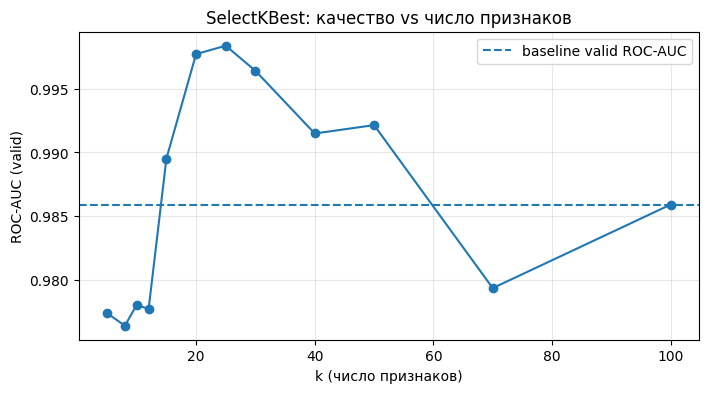

In [ ]:
# Выбираем минимальное k, при котором падение ROC-AUC < 2%
ok_selectk = selectk_results[selectk_results["auc_drop_pct_vs_baseline"] < 2]

if len(ok_selectk) > 0:
    # Берём самое «компактное» решение
    best_k = int(ok_selectk["k"].min())
else:
    # Если строгий критерий не выполнился, берём k с максимальным ROC-AUC
    best_k = int(selectk_results.loc[selectk_results["roc_auc"].idxmax(), "k"])

print("Выбранный best_k:", best_k)

# Визуализация зависимости качества от числа оставленных признаков
plt.figure(figsize=(8, 4))
plt.plot(selectk_results["k"], selectk_results["roc_auc"], marker="o")
plt.axhline(
    baseline_valid["roc_auc"],
    linestyle="--",
    label="baseline valid ROC-AUC"
)
plt.xlabel("k (число признаков)")
plt.ylabel("ROC-AUC (valid)")
plt.title("SelectKBest: качество vs число признаков")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Теперь переобучаем модели на dev = train + valid, затем оцениваем на test.

# 1) Baseline (все признаки)
baseline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])
baseline_test = fit_and_eval(baseline_final, X_dev, y_dev, X_test, y_test)

# 2) SelectKBest(best_k)
selectk_final = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=best_k)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])
selectk_test = fit_and_eval(selectk_final, X_dev, y_dev, X_test, y_test)

# Чтобы увидеть, какие исходные признаки отобраны:
selectk_final.fit(X_dev, y_dev)
selected_k_names = X.columns[selectk_final.named_steps["select"].get_support()].tolist()

# Падение качества на test относительно baseline
selectk_drop_test = drop_pct(selectk_test["roc_auc"], baseline_test["roc_auc"])

print("SelectKBest выбранные признаки:")
print(selected_k_names)
print("\nПадение ROC-AUC vs baseline (test), %:", round(selectk_drop_test, 4))

# Сравнительная таблица
pd.DataFrame([
    {"method": "baseline_all_features", **baseline_test, "n_features": X.shape[1]},
    {"method": f"selectkbest_k={best_k}", **selectk_test, "n_features": best_k},
]).round(4)


SelectKBest выбранные признаки:
['mean perimeter', 'mean concave points', 'worst radius', 'worst perimeter', 'worst concave points']

Падение ROC-AUC vs baseline (test), %: -1.2838


,method,roc_auc,f1,fit_sec,n_features
0,baseline_all_features,0.9788,0.9577,0.0157,100
1,selectkbest_k=5,0.9914,0.9429,0.0082,5


### <h3><b>4. RFE: wrapper-отбор с учётом модели</b></h3>

`RFE` рекурсивно удаляет наименее важные признаки, каждый раз переобучая модель.  

- Мы перебираем несколько значений `n_features_to_select` и для каждого запускаем один и тот же пайплайн, чтобы сравнение было корректным.  
- Затем считаем метрики на `valid`  и выбираем самое компактное решение, которое укладывается в допустимую просадку качества, например не более 2%.  
- Такой подход часто даёт более «связанный» набор признаков, потому что важность оценивается в контексте конкретной модели, а не по каждому признаку отдельно.

**Шаги:**

1. Используем базовая модель внутри RFE — `RFE(estimator=LogisticRegression(...), n_features_to_select=n, step=...)`.

2. Для каждого `n` обучаем модель и считаем ROC-AUC/F1/время на `valid`.

3. Через `drop_pct(...)` проверяем, укладываемся ли в критерий `<2%` относительно модели на всех признаках.

4. Берём минимальное `n`, при котором качество остаётся в допустимом диапазоне.

5. Используем `get_support()` для возвращения маски отобранных колонок.

---

**Чем отличается от SelectKBest**

- `SelectKBest` оценивает признаки по одному (univariate).  
- `RFE` оценивает вклад признаков в контексте конкретной модели (model-aware).


In [ ]:
# Сетка числа признаков для RFE
n_grid = [1, 5, 8, 10, 12, 15, 20, 25, 30, 40, 50]

rows = []
for n in n_grid:
    # Важно: в RFE оценка важности идет через базовую модель (estimator внутри RFE)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(
            estimator=LogisticRegression(
                max_iter=3000,
                solver="liblinear",
                random_state=RANDOM_STATE
            ),
            n_features_to_select=n,  # сколько признаков оставить
            step=5                    # сколько признаков удалять на каждом шаге
        )),
        ("clf", LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ])

    # Оценка на validation
    m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
    rows.append({"n_features": n, **m})

# Таблица результатов RFE
rfe_results = pd.DataFrame(rows).sort_values("n_features").reset_index(drop=True)

# Падение ROC-AUC относительно baseline
rfe_results["auc_drop_pct_vs_baseline"] = drop_pct(
    rfe_results["roc_auc"],
    baseline_valid["roc_auc"]
)

rfe_results.round(4)


,n_features,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,1,0.9466,0.9139,0.0632,3.9867
1,5,0.9830,0.9722,0.0592,0.2990
2,8,0.9921,0.9726,0.0524,-0.6312
3,10,0.9934,0.9583,0.0511,-0.7641
4,12,0.9912,0.9437,0.0545,-0.5316
5,15,0.9872,0.9510,0.0635,-0.1329
6,20,0.9820,0.9577,0.0488,0.3987
7,25,0.9836,0.9517,0.0515,0.2326
8,30,0.9862,0.9577,0.0477,-0.0332
9,40,0.9846,0.9655,0.0487,0.1329


Выбранный best_n_rfe: 5


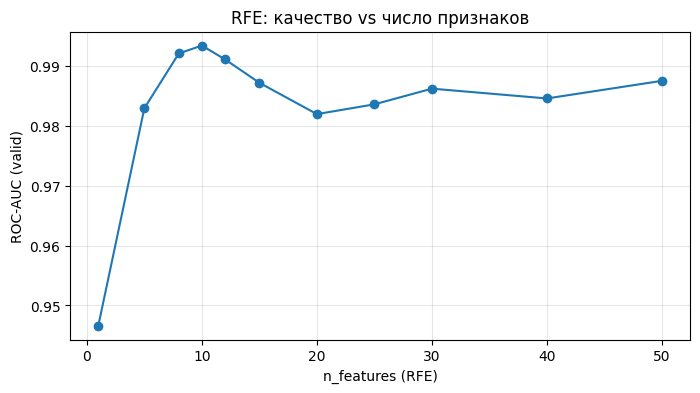

In [ ]:
# Выбираем минимальное число признаков, где падение < 2%
ok_rfe = rfe_results[rfe_results["auc_drop_pct_vs_baseline"] < 2]

if len(ok_rfe) > 0:
    best_n_rfe = int(ok_rfe["n_features"].min())
else:
    best_n_rfe = int(rfe_results.loc[rfe_results["roc_auc"].idxmax(), "n_features"])

print("Выбранный best_n_rfe:", best_n_rfe)

# График качества RFE от числа признаков
plt.figure(figsize=(8, 4))
plt.plot(rfe_results["n_features"], rfe_results["roc_auc"], marker="o")
plt.xlabel("n_features (RFE)")
plt.ylabel("ROC-AUC (valid)")
plt.title("RFE: качество vs число признаков")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Теперь переобучаем модели на dev = train + valid, затем оцениваем на test.

rfe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("rfe", RFE(
        estimator=LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ),
        n_features_to_select=best_n_rfe,
        step=5
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

# Метрики на test
rfe_test = fit_and_eval(rfe_final, X_dev, y_dev, X_test, y_test)

# Список выбранных признаков
rfe_final.fit(X_dev, y_dev)
selected_rfe_names = X.columns[rfe_final.named_steps["rfe"].get_support()].tolist()

# Процент потери ROC-AUC относительно baseline
rfe_drop_test = drop_pct(rfe_test["roc_auc"], baseline_test["roc_auc"])

print("RFE выбранные признаки:")
print(selected_rfe_names)
print("\nПадение ROC-AUC vs baseline (test), %:", round(rfe_drop_test, 4))


RFE выбранные признаки:
['radius error', 'worst radius', 'worst texture', 'worst perimeter', 'worst concave points']

Падение ROC-AUC vs baseline (test), %: -1.6216


In [ ]:
# Объединяем результаты baseline / SelectKBest / RFE в одну таблицу
comparison_fs = pd.DataFrame([
    {"method": "baseline_all_features", **baseline_test, "n_features": X.shape[1]},
    {"method": f"selectkbest_k={best_k}", **selectk_test, "n_features": best_k},
    {"method": f"rfe_n={best_n_rfe}", **rfe_test, "n_features": best_n_rfe},
])

# Добавляем Рост ROC-AUC vs baseline
comparison_fs["auc_drop_pct_vs_baseline"] = drop_pct(
    -comparison_fs["roc_auc"],
    -baseline_test["roc_auc"]
)

comparison_fs.round(4)


,method,roc_auc,f1,fit_sec,n_features,auc_drop_pct_vs_baseline
0,baseline_all_features,0.9788,0.9577,0.0145,100,-0.0000
1,selectkbest_k=5,0.9914,0.9429,0.0082,5,-1.2838
2,rfe_n=5,0.9947,0.9583,0.1350,5,-1.6216


##### Короткий вывод по feature selection

- Мы сократили число признаков, сохранив качество модели.
- SelectKBest и RFE могут выбирать разные наборы признаков:
  - Filter-метод оценивает признак **вне** контекста конкретной модели.
  - Wrapper-метод оценивает признак **через** качество модели.


In [ ]:
# Сравнение выбранных признаков
# selected_k_names  -> из SelectKBest
# selected_rfe_names -> из RFE

sel = set(selected_k_names)
rfe = set(selected_rfe_names)

common = sorted(sel & rfe)
only_sel = sorted(sel - rfe)
only_rfe = sorted(rfe - sel)

print("Общие признаки (SelectKBest ∩ RFE):")
print(common)

print("\nТолько SelectKBest:")
print(only_sel)

print("\nТолько RFE:")
print(only_rfe)


Общие признаки (SelectKBest ∩ RFE):
['worst concave points', 'worst perimeter', 'worst radius']

Только SelectKBest:
['mean concave points', 'mean perimeter']

Только RFE:
['radius error', 'worst texture']


### <h3><b>5. PCA: понижение размерности через новые компоненты</b></h3>

`PCA` не выбирает исходные признаки, а строит новые ортогональные компоненты.  

- Мы перебираем несколько значений `n_components` и для каждого обучаем одну и ту же модель.  
- Затем оцениваем метрики на валидации и выбираем самое компактное решение, которое укладывается в допустимую просадку качества, например не более 2%.  
- Такой подход уменьшает размерность, часто ускоряет обучение и позволяет визуализировать данные в 2D/3D через главные компоненты.

**Шаги:**

1. Масштабирование перед PCA — `StandardScaler()` обязателен, иначе признаки с крупным масштабом доминируют.

2. Считаем долю объяснённой дисперсии — `explained_variance_ratio_` и `np.cumsum(...)` показывают, сколько информации сохраняют первые компоненты.

3. Подбираем число компонент — через `np.searchsorted(cum_var, 0.95)` как минимальное число компонент для 95% дисперсии.

4. Для каждого `n_components` обучается пайплайн `Scaler -> PCA -> LogisticRegression` и считаются метрики на `valid`.

5. Сравниваем относительно модели, обученной на всех признаках, и проверяем ограничение по потере качества.

6. Используем `components_` для интерпретации вкладов исходных признаков в PC1/PC2 (loadings).

---

PCA особенно полезен, когда важны компактное представление данных, скорость и устойчивая работа модели на высокоразмерных признаках.


Число компонент для >=95% explained variance: 69


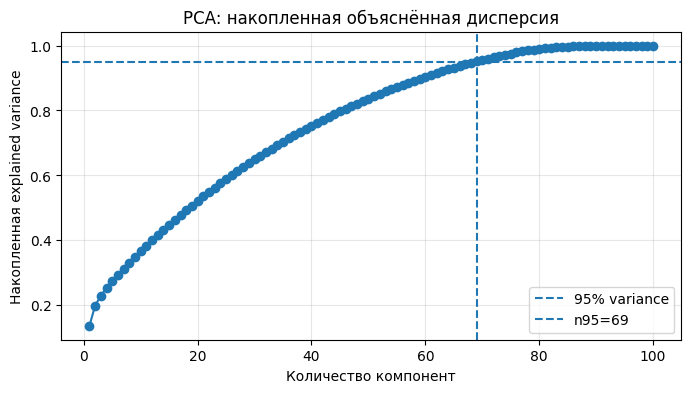

In [ ]:
# PCA на обучающей части (только X_train), чтобы оценить explained variance
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

# Накопленная доля объяснённой дисперсии
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Минимальное число компонент для >=95% дисперсии
n95 = int(np.searchsorted(cum_var, 0.95) + 1)

print("Число компонент для >=95% explained variance:", n95)

# График накопленной explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.axvline(n95, linestyle="--", label=f"n95={n95}")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная explained variance")
plt.title("PCA: накопленная объяснённая дисперсия")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Подбираем число PCA-компонент по quality-критерию на valid
# (хотим падение ROC-AUC < 2%)
comp_grid = sorted(set([2, 3, 5, 8, 10, 12, 15, 20, 25, 30, n95]))
comp_grid = [c for c in comp_grid if c <= X.shape[1]]

rows = []
for n_comp in comp_grid:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ])

    m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
    rows.append({"n_components": n_comp, **m})

# Таблица результатов по разным n_components
pca_results = pd.DataFrame(rows).sort_values("n_components").reset_index(drop=True)

# Падение ROC-AUC относительно baseline
pca_results["auc_drop_pct_vs_baseline"] = drop_pct(
    pca_results["roc_auc"],
    baseline_valid["roc_auc"]
)

pca_results.round(4)


,n_components,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,2,0.9856,0.9571,0.0303,0.0332
1,3,0.9876,0.9504,0.0154,-0.1661
2,5,0.9938,0.9790,0.0135,-0.7973
3,8,0.9951,0.9859,0.0108,-0.9302
4,10,0.9908,0.9718,0.0110,-0.4983
5,12,0.9941,0.9790,0.0103,-0.8306
6,15,0.9944,0.9790,0.0119,-0.8638
7,20,0.9934,0.9655,0.0135,-0.7641
8,25,0.9885,0.9722,0.0230,-0.2658
9,30,0.9846,0.9583,0.0407,0.1329


Выбранный best_n_pca: 2


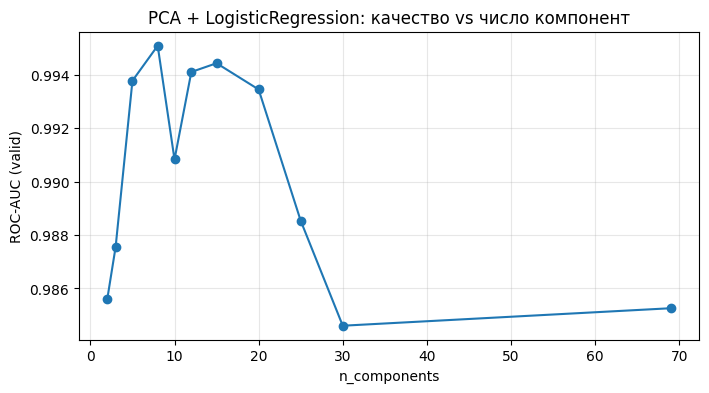

In [ ]:
# Выбираем минимальное число компонент, где падение ROC-AUC < 2%
ok_pca = pca_results[pca_results["auc_drop_pct_vs_baseline"] < 2]

if len(ok_pca) > 0:
    best_n_pca = int(ok_pca["n_components"].min())
else:
    # Если критерий не выполняется, берём вариант с лучшим ROC-AUC
    best_n_pca = int(pca_results.loc[pca_results["roc_auc"].idxmax(), "n_components"])

print("Выбранный best_n_pca:", best_n_pca)

# График качества в зависимости от числа компонент
plt.figure(figsize=(8, 4))
plt.plot(pca_results["n_components"], pca_results["roc_auc"], marker="o")
plt.xlabel("n_components")
plt.ylabel("ROC-AUC (valid)")
plt.title("PCA + LogisticRegression: качество vs число компонент")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Финальная PCA-модель: обучаем на dev, оцениваем на test
pca_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_n_pca, random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

pca_test = fit_and_eval(pca_final, X_dev, y_dev, X_test, y_test)

# Падение ROC-AUC относительно baseline на test
pca_drop_test = drop_pct(pca_test["roc_auc"], baseline_test["roc_auc"])

# Сводная таблица baseline vs PCA
summary = pd.DataFrame([
    {"method": "baseline_all_features", **baseline_test, "dim": X.shape[1]},
    {"method": f"pca_{best_n_pca}_components", **pca_test, "dim": best_n_pca},
])

summary["auc_drop_pct_vs_baseline"] = drop_pct(summary["roc_auc"], baseline_test["roc_auc"])
summary["speedup_vs_baseline_fit"] = baseline_test["fit_sec"] / summary["fit_sec"]  # >1 => PCA быстрее

print("Падение ROC-AUC vs baseline (test), %:", round(pca_drop_test, 4))
summary.round(4)


Падение ROC-AUC vs baseline (test), %: -0.8446


,method,roc_auc,f1,fit_sec,dim,auc_drop_pct_vs_baseline,speedup_vs_baseline_fit
0,baseline_all_features,0.9788,0.9577,0.0157,100,0.0000,1.0000
1,pca_2_components,0.9871,0.9437,0.0463,2,-0.8446,0.3386


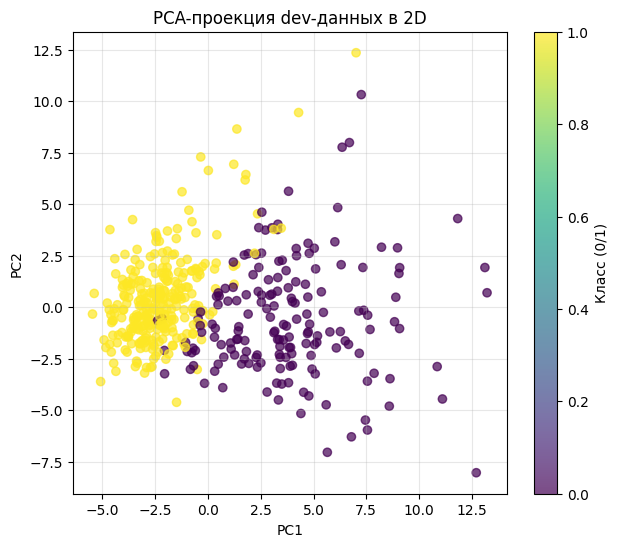

In [ ]:
# Визуализация данных в 2D при помощи PCA
pca_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE))
])

# Преобразуем dev-набор в 2 главные компоненты
X_dev_2d = pca_2d.fit_transform(X_dev)

# scatter-диаграмма: точки окрашены по классу
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_dev_2d[:, 0], X_dev_2d[:, 1], c=y_dev, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA-проекция dev-данных в 2D")
plt.grid(alpha=0.3)
plt.colorbar(scatter, label="Класс (0/1)")
plt.show()


- На графике каждая точка — объект, цвет — класс, а оси PC1 и PC2 — две главные компоненты PCA.
- Видно, что классы в основном разделяются по PC1 (по горизонтали), а PC2 даёт дополнительное, но более слабое разделение.
- В центре есть пересечение классов, поэтому разделение в 2D хорошее, но не идеальное.


### <h3><b>6. Итоговая проверка </b></h3>

Соберём итоговую таблицу, где сможем сравнить все меотоды.

Проверяем:

1. **Снижение размерности** — было `dim_before`, стало `dim_after`.

2. **Ограничение по качеству** — потеря ROC-AUC относительно baseline < 2%.

3. **Скорость обучения** — сравниваем `fit_sec`.

4. **Интерпретируемость**  
   - для FS: список выбранных исходных признаков,  
   - для PCA: ключевые loadings компонент.

---

Метод считается успешным, если он уменьшает размерность,  
сохраняет качество в заданном коридоре и делает модель проще в эксплуатации.


In [ ]:
# Проверяем все методы в виде итоговой таблицы
result_checks = pd.DataFrame([
    {
        "result": "SelectKBest",
        "dim_before": X.shape[1],            # размерность до
        "dim_after": best_k,                 # размерность после
        "auc_drop_pct_test": selectk_drop_test,
        "criterion_pass": selectk_drop_test < 2
    },
    {
        "result": "RFE",
        "dim_before": X.shape[1],
        "dim_after": best_n_rfe,
        "auc_drop_pct_test": rfe_drop_test,
        "criterion_pass": rfe_drop_test < 2
    },
    {
        "result": "PCA",
        "dim_before": X.shape[1],
        "dim_after": best_n_pca,
        "auc_drop_pct_test": pca_drop_test,
        "criterion_pass": pca_drop_test < 2
    }
])

result_checks.round(4)


,result,dim_before,dim_after,auc_drop_pct_test,criterion_pass
0,SelectKBest,100,5,-1.2838,True
1,RFE,100,5,-1.6216,True
2,PCA,100,2,-0.8446,True


**Вывод:**
- Все три подхода успешно сократили размерность и прошли критерий качества (criterion_pass = True).

- Потери ROC-AUC нет: во всех случаях auc_drop_pct_test < 0, то есть качество даже немного выросло.

- SelectKBest и RFE сократили признаки с 100 до 5, а PCA — до 2 (самое сильное сжатие).

- По качеству лучший прирост у RFE (-1.6216%), при этом PCA даёт максимальную компактность, а SelectKBest — хороший баланс простоты и качества.



